## Transcript data details 
Transcripts and audios were redacted for privacy reasons

In [1]:
import pandas as pd

df=pd.read_csv('data.csv')
print(df.shape)

print("words in first row:", len(df.iloc[0]['text'].split()))

df.head(10)

(61504, 1)
words in first row: 644


,text
0,Please press [PHONE_NUMBER] to discuss an appo...
1,Thank you for calling [ORGANIZATION] [ORGANIZA...
2,Good afternoon. Thank you for calling [ORGANIZ...
3,"Thank you for calling [ORGANIZATION], a forefr..."
4,"[ORGANIZATION] [ORGANIZATION] [ORGANIZATION], ..."
5,"Hello, this is [PERSON_NAME] [PERSON_NAME], [O..."
6,Thank you for calling [ORGANIZATION] [ORGANIZA...
7,Thank you for calling [ORGANIZATION] [ORGANIZA...
8,Thank you for calling [ORGANIZATION] [ORGANIZA...
9,Thank you for calling [ORGANIZATION] [ORGANIZA...


### Words in a particular transcript

# Using pre-trained BERT
 To generate embeddings of transcripts 

In [2]:
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import BertTokenizer, BertModel,AutoTokenizer, AutoModel

# ============================================================
# CONFIGURATION
# ============================================================

INPUT_CSV = "data.csv"
OUTPUT_CSV = "embeddings.csv"
SAMPLED_TEXTS_CSV = "sampled_transcripts.csv"  # Added output path for transcripts

TEXT_COLUMN = "text"

NUM_TRANSCRIPTS = 1000      # None -> Process entire dataset

RANDOM_SEED = 42

MAX_LENGTH = 512            # BERT maximum
CHUNK_SIZE = 510            # 510 + CLS + SEP = 512

BATCH_SIZE = 64           # Increase if GPU has more VRAM

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_CSV)

if NUM_TRANSCRIPTS is not None:
    df = (
        df.sample(
            n=min(NUM_TRANSCRIPTS, len(df)),
            random_state=RANDOM_SEED
        )
        .reset_index(drop=True)
    )

print(f"Transcripts selected : {len(df)}")

# ============================================================
# LOAD MODEL
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertModel.from_pretrained("bert-base-uncased")

# tokenizer = AutoTokenizer.from_pretrained(
#     "sentence-transformers/all-mpnet-base-v2"
# )

# model = AutoModel.from_pretrained(
#     "sentence-transformers/all-mpnet-base-v2"
# )

model.to(device)
model.eval()

# ============================================================
# BUILD ALL CHUNKS
# ============================================================

all_chunks = []
transcript_map = []

print("\nCreating chunks...")

for idx, text in tqdm(enumerate(df[TEXT_COLUMN]),
                      total=len(df)):

    text = str(text)

    tokens = tokenizer.encode(
        text,
        add_special_tokens=False
    )

    for i in range(0, len(tokens), CHUNK_SIZE):

        chunk = tokens[i:i + CHUNK_SIZE]

        chunk = (
            [tokenizer.cls_token_id]
            + chunk +
            [tokenizer.sep_token_id]
        )

        all_chunks.append(chunk)

        transcript_map.append(idx)

print(f"\nTotal chunks : {len(all_chunks)}")

# ============================================================
# GENERATE EMBEDDINGS
# ============================================================

chunk_embeddings = []

print("\nGenerating chunk embeddings...")

for start in tqdm(
    range(0, len(all_chunks), BATCH_SIZE)
):

    batch = all_chunks[start:start+BATCH_SIZE]

    encoding = tokenizer.pad(
        {"input_ids": batch},
        padding=True,
        return_tensors="pt"
    )

    encoding = {
        k: v.to(device)
        for k, v in encoding.items()
    }

    with torch.no_grad():

        outputs = model(**encoding)

        # Mean Pooling over tokens
        embeddings = outputs.last_hidden_state.mean(dim=1)

    chunk_embeddings.extend(
        embeddings.cpu().numpy()
    )

# ============================================================
# COMBINE CHUNKS OF SAME TRANSCRIPT
# ============================================================

print("\nCombining chunks...")

transcript_embeddings = [[] for _ in range(len(df))]

for emb, transcript_idx in zip(
    chunk_embeddings,
    transcript_map
):

    transcript_embeddings[transcript_idx].append(emb)

final_embeddings = []

for emb_list in transcript_embeddings:

    emb = np.mean(
        emb_list,
        axis=0
    )

    final_embeddings.append(emb)

# ============================================================
# SAVE
# ============================================================

embedding_df = pd.DataFrame(final_embeddings)

embedding_df.to_csv(
    OUTPUT_CSV,
    index=False
)

# Save the sampled text transcripts in the exact corresponding order
df[[TEXT_COLUMN]].to_csv(
    SAMPLED_TEXTS_CSV,
    index=False
)

print("\n====================================")
print("Finished Successfully!")
print("====================================")
print("Embeddings Shape    :", embedding_df.shape)
print("Saved Embeddings to :", OUTPUT_CSV)
print("Saved Transcripts to:", SAMPLED_TEXTS_CSV)

Transcripts selected : 1000
Device : cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Creating chunks...


100%|██████████| 1000/1000 [00:02<00:00, 444.92it/s]



Total chunks : 2536

Generating chunk embeddings...


100%|██████████| 40/40 [01:33<00:00,  2.35s/it]



Combining chunks...

Finished Successfully!
Embeddings Shape    : (1000, 768)
Saved Embeddings to : embeddings.csv
Saved Transcripts to: sampled_transcripts.csv


### Using PCA

Original Shape: (1000, 768)
Reduced Shape: (1000, 2)

Explained Variance Ratio
PC1 : 0.1813
PC2 : 0.1073
Total : 0.2886


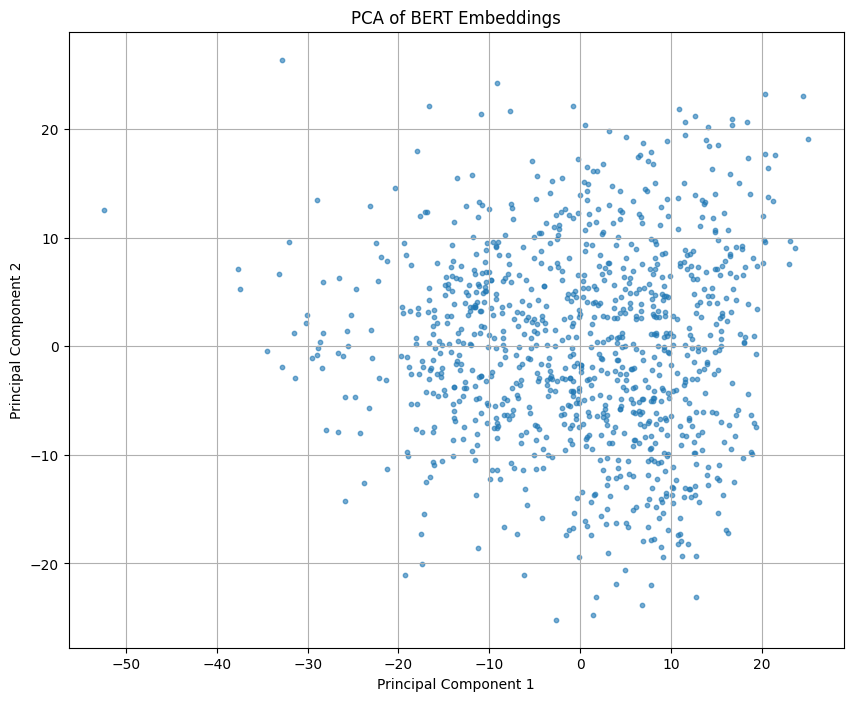

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =====================================
# Load Embeddings
# =====================================

embeddings = pd.read_csv("embeddings.csv")

print("Original Shape:", embeddings.shape)

# =====================================
# Standardize Features
# =====================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(embeddings)

# =====================================
# Apply PCA
# =====================================

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print("Reduced Shape:", X_pca.shape)

# =====================================
# Explained Variance
# =====================================

print("\nExplained Variance Ratio")

print(f"PC1 : {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2 : {pca.explained_variance_ratio_[1]:.4f}")

print(
    f"Total : {sum(pca.explained_variance_ratio_):.4f}"
)

# =====================================
# Scatter Plot
# =====================================

plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=10,
    alpha=0.6
)

plt.title("PCA of BERT Embeddings")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

In [4]:
e=pd.read_csv('sampled_transcripts.csv')
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)
e_=pd.concat([e, pca_df], axis=1)

pca_df.to_csv("pca_embeddings.csv", index=False)

### UMAP

Original Shape: (1000, 768)


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced Shape: (1000, 2)


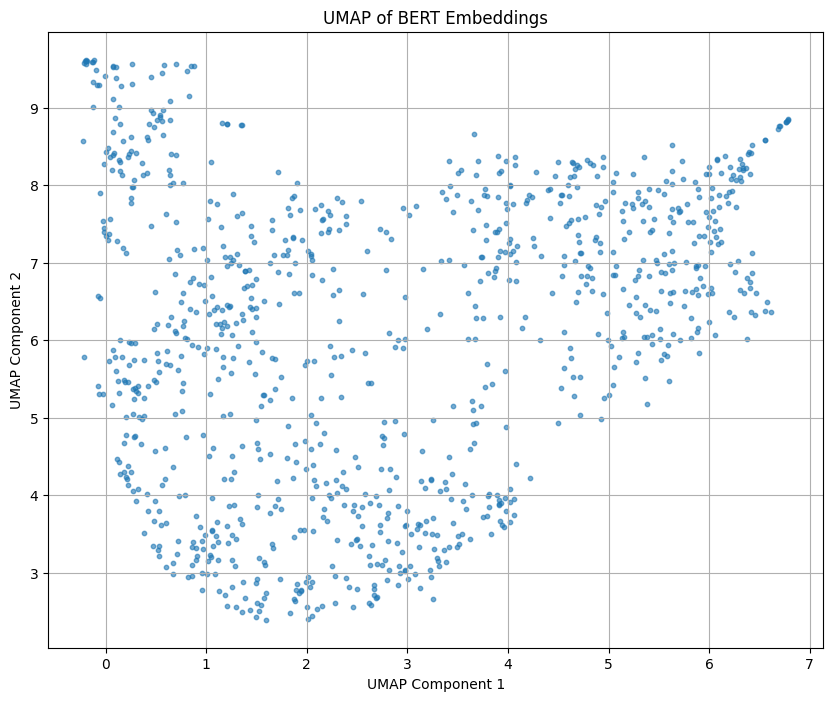

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

# =====================================
# Load Embeddings
# =====================================

embeddings = pd.read_csv("embeddings.csv")

print("Original Shape:", embeddings.shape)

# =====================================
# Standardize
# =====================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(embeddings)

# =====================================
# UMAP
# =====================================

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

print("Reduced Shape:", X_umap.shape)

# =====================================
# Plot
# =====================================

plt.figure(figsize=(10,8))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    s=10,
    alpha=0.6
)

plt.title("UMAP of BERT Embeddings")

plt.xlabel("UMAP Component 1")

plt.ylabel("UMAP Component 2")

plt.grid(True)

plt.show()

In [6]:
umap_df = pd.DataFrame(
    X_umap,
    columns=["UMAP1", "UMAP2"]
)
e_2=pd.concat([e_, umap_df], axis=1)
umap_df.to_csv("umap_embeddings.csv", index=False)
e_2.to_csv("sampled_transcripts.csv", index=False)

## Isolation Forest


In [7]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# Load embeddings
embeddings = pd.read_csv("embeddings.csv")

# Train Isolation Forest
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iso.fit(embeddings)

# Predict BEFORE modifying the dataframe
predictions = iso.predict(embeddings)
scores = -iso.score_samples(embeddings)

# Now add the results
e=pd.read_csv('sampled_transcripts.csv')
e["iso_prediction"] = predictions
e["iso_score"] = scores


In [8]:
print(e["iso_prediction"].value_counts())

iso_prediction
 1    950
-1     50
Name: count, dtype: int64


## DBSCAN

In [9]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# ===================================
# Load Embeddings
# ===================================

embeddings = pd.read_csv("embeddings.csv")

# ===================================
# Standardize
# ===================================

scaler = StandardScaler()

X = scaler.fit_transform(embeddings)

# ===================================
# DBSCAN
# ===================================

dbscan = DBSCAN(
    eps=0.30,
    min_samples=5,
    metric="cosine",
    n_jobs=-1
)

clusters = dbscan.fit_predict(X)
print("Clusters found :", len(set(clusters)) - (1 if -1 in clusters else 0))

print("Noise points :", (clusters == -1).sum())

print("Noise % :", (clusters == -1).mean() * 100)

e["cluster"] = clusters

print(e["cluster"].value_counts())

Clusters found : 4
Noise points : 880
Noise % : 88.0
cluster
-1    880
 1     52
 3     27
 2     21
 0     20
Name: count, dtype: int64


In [10]:
noise = embeddings[
    e["cluster"] == -1
]

print(noise.shape)

(880, 768)


In [11]:
e.to_csv("transcripts_dbscan_iso.csv", index=False)

print(e.head())

                                                text        PC1        PC2  \
0  Thank you for calling [ORGANIZATION] [ORGANIZA... -11.111176  -2.871231   
1  Good morning. Thank you for calling [ORGANIZAT...  -8.273556   6.279498   
2  Thank you for calling [ORGANIZATION] [ORGANIZA...   7.589132   5.754297   
3  Thank you for calling [ORGANIZATION] [ORGANIZA... -14.619458   2.162938   
4  Thank you for calling [ORGANIZATION] [ORGANIZA...   8.639485 -15.849948   

      UMAP1     UMAP2  iso_prediction  iso_score  cluster  
0  5.247957  8.149521               1   0.411650       -1  
1  3.994715  7.690164               1   0.396458       -1  
2  1.356955  6.335519               1   0.386195       -1  
3  4.902317  7.627544               1   0.422336       -1  
4  1.923954  2.732240               1   0.424782       -1  


In [12]:
top = e.sort_values(
    "iso_score",
    ascending=False
)

top[["text","iso_score","cluster"]].head(20)

,text,iso_score,cluster
613,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.636415,-1
684,[ORGANIZATION] [ORGANIZATION] [ORGANIZATION] [...,0.628323,-1
678,[ORGANIZATION]. [ORGANIZATION] [ORGANIZATION]....,0.607344,-1
322,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.594550,-1
524,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.585999,-1
831,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.581839,-1
568,[PERSON_NAME] can [PERSON_NAME] speaking how m...,0.574784,-1
412,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.567976,-1
43,Thank you for calling [ORGANIZATION] [ORGANIZA...,0.565451,2
655,"[ORGANIZATION] [ORGANIZATION], how can I help ...",0.561404,-1


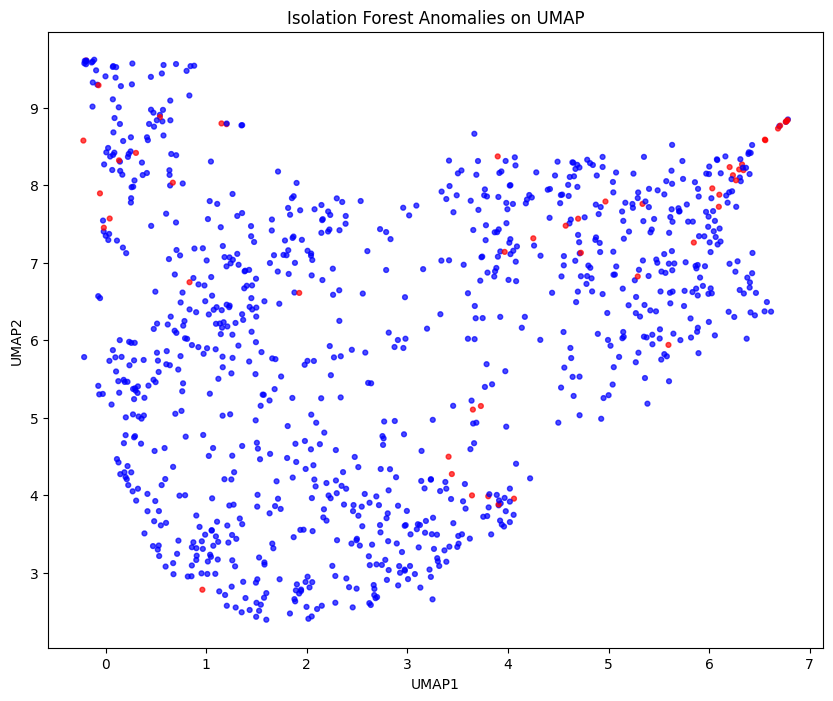

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

colors = e["iso_prediction"].map({
    1: "blue",
    -1: "red"
})

plt.scatter(
    e["UMAP1"],
    e["UMAP2"],
    c=colors,
    s=12,
    alpha=0.7
)

plt.title("Isolation Forest Anomalies on UMAP")

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.show()

### Sentiment analysis

In [14]:
import pandas as pd
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# =====================================
# Load your current dataframe
# =====================================

df = pd.read_csv("transcripts_dbscan_iso.csv")   # Change filename if needed

# =====================================
# Initialize VADER
# =====================================

analyzer = SentimentIntensityAnalyzer()

neg_scores = []
neu_scores = []
pos_scores = []
compound_scores = []

# =====================================
# Analyze Sentiment
# =====================================

for text in tqdm(df["text"], desc="Running VADER"):

    scores = analyzer.polarity_scores(str(text))

    neg_scores.append(scores["neg"])
    neu_scores.append(scores["neu"])
    pos_scores.append(scores["pos"])
    compound_scores.append(scores["compound"])

# =====================================
# Add to DataFrame
# =====================================

df["sent_neg"] = neg_scores
df["sent_neu"] = neu_scores
df["sent_pos"] = pos_scores
df["sent_compound"] = compound_scores

# =====================================
# Save
# =====================================



print("Done!")
print(df.head())

Running VADER: 100%|██████████| 1000/1000 [00:16<00:00, 60.67it/s]

Done!
                                                text        PC1        PC2  \
0  Thank you for calling [ORGANIZATION] [ORGANIZA... -11.111176  -2.871231   
1  Good morning. Thank you for calling [ORGANIZAT...  -8.273556   6.279498   
2  Thank you for calling [ORGANIZATION] [ORGANIZA...   7.589132   5.754297   
3  Thank you for calling [ORGANIZATION] [ORGANIZA... -14.619458   2.162938   
4  Thank you for calling [ORGANIZATION] [ORGANIZA...   8.639485 -15.849948   

      UMAP1     UMAP2  iso_prediction  iso_score  cluster  sent_neg  sent_neu  \
0  5.247957  8.149521               1   0.411650       -1     0.021     0.838   
1  3.994715  7.690164               1   0.396458       -1     0.007     0.800   
2  1.356955  6.335519               1   0.386195       -1     0.015     0.854   
3  4.902317  7.627544               1   0.422336       -1     0.020     0.757   
4  1.923954  2.732240               1   0.424782       -1     0.033     0.779   

   sent_pos  sent_compound  
0     0.1

### Risk Engine

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["iso_norm"] = scaler.fit_transform(df[["iso_score"]])

In [16]:
df["dbscan_outlier"] = (df["cluster"] == -1).astype(int)

In [17]:
ISO_WEIGHT = 70

DBSCAN_WEIGHT = 10

NEG_WEIGHT = 15

POS_WEIGHT = 5

In [18]:
df["risk_score"] = (

ISO_WEIGHT * df["iso_norm"]

+

DBSCAN_WEIGHT * df["dbscan_outlier"]

+

NEG_WEIGHT * df["sent_neg"]

-

POS_WEIGHT * df["sent_pos"]

)

In [19]:
df["risk_score"] = df["risk_score"].clip(0,100)

In [20]:
print(df["risk_score"].describe())

count    1000.000000
mean       23.506142
std         8.730593
min         5.513856
25%        17.780825
50%        21.868587
75%        27.309475
max        79.270000
Name: risk_score, dtype: float64


In [21]:
def risk_level(score):

    if score >= 70:
        return "High"

    elif score >= 40:
        return "Medium"

    else:
        return "Low"

df["risk_level"] = df["risk_score"].apply(risk_level)

In [22]:
df["iso_contribution"] = ISO_WEIGHT * df["iso_norm"]
df["dbscan_contribution"] = DBSCAN_WEIGHT * df["dbscan_outlier"]
df["neg_contribution"] = NEG_WEIGHT * df["sent_neg"]
df["pos_contribution"] = -POS_WEIGHT * df["sent_pos"]

In [23]:
high_risk = df.sort_values(
    "risk_score",
    ascending=False
)

print(
    high_risk.head(20)
)

                                                  text        PC1        PC2  \
613  Thank you for calling [ORGANIZATION] [ORGANIZA... -31.475382   1.176838   
684  [ORGANIZATION] [ORGANIZATION] [ORGANIZATION] [... -28.360832   1.247808   
678  [ORGANIZATION]. [ORGANIZATION] [ORGANIZATION].... -52.446430  12.514516   
322  Thank you for calling [ORGANIZATION] [ORGANIZA... -28.918495  13.415260   
524  Thank you for calling [ORGANIZATION] [ORGANIZA... -32.807271  26.367789   
831  Thank you for calling [ORGANIZATION] [ORGANIZA... -32.772036  -1.913901   
568  [PERSON_NAME] can [PERSON_NAME] speaking how m... -10.592485   1.731861   
412  Thank you for calling [ORGANIZATION] [ORGANIZA... -37.639509   7.112916   
655  [ORGANIZATION] [ORGANIZATION], how can I help ... -19.060825  -0.967718   
300  Thank you for calling [ORGANIZATION] [ORGANIZA...  18.976080   8.116137   
504  Yeah, that's fine. Thank you. So, basically, t... -37.394855   5.261668   
135  Thank you for calling [ORGANIZATION

In [24]:
df.to_csv(
    "risk_engine_results.csv",
    index=False
)

print("Risk engine completed successfully!")

Risk engine completed successfully!


In [25]:
print(df["risk_level"].value_counts())

risk_level
Low       959
Medium     38
High        3
Name: count, dtype: int64


In [26]:
df.to_csv("final_results.csv", index=False)

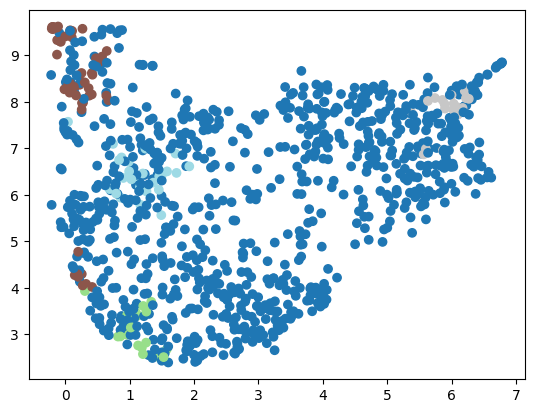

In [27]:
plt.scatter(
    e["UMAP1"],
    e["UMAP2"],
    c=e["cluster"],
    cmap="tab20"
)

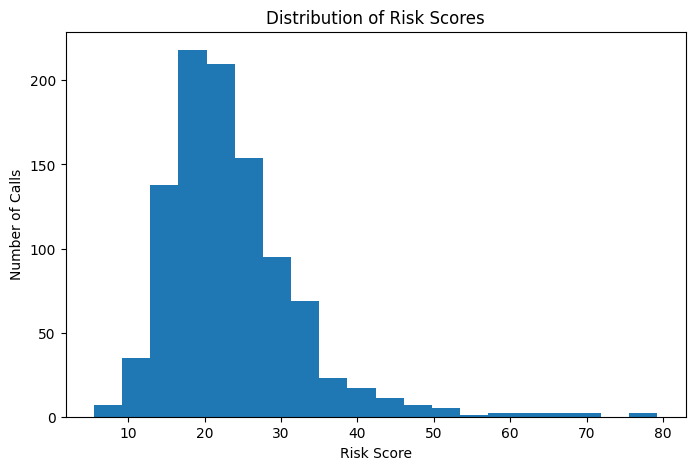

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df["risk_score"], bins=20)

plt.xlabel("Risk Score")
plt.ylabel("Number of Calls")
plt.title("Distribution of Risk Scores")

plt.show()